In [14]:
pip install merlin-vlm

Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install datasets huggingface_hub nibabel numpy torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [16]:
import os, json, numpy as np, nibabel as nib, torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_ROOT = os.path.expanduser("~/Documents/GitHub/fyp-3d-ct/models/merlin")
DATA_ROOT    = os.path.join(PROJECT_ROOT, "data")
VOLUMES_DIR  = os.path.join(DATA_ROOT, "data_volumes")
REXCT_DIR    = os.path.join(DATA_ROOT, "rexgrounding-ct")
DATASET_JSON = os.path.join(REXCT_DIR, "dataset.json")

os.makedirs("results", exist_ok=True)
print("Paths set.")

Paths set.


In [17]:
ct_index = {}
for root, dirs, files in os.walk(VOLUMES_DIR):
    for f in files:
        if f.endswith(".nii.gz"):
            ct_index[f] = os.path.join(root, f)

print(f"CT files found: {len(ct_index)}")
for name in ct_index:
    print(f"  {name}")

CT files found: 169
  train_108_a_2.nii.gz
  train_34_a_2.nii.gz
  train_33_a_1.nii.gz
  train_106_a_1.nii.gz
  train_93_c_2.nii.gz
  train_93_d_2.nii.gz
  train_67_a_2.nii.gz
  train_60_d_1.nii.gz
  train_56_a_1.nii.gz
  train_197_a_2.nii.gz
  train_563_a_2.nii.gz
  train_107_c_2.nii.gz
  train_107_b_2.nii.gz
  train_107_a_1.nii.gz
  train_332_a_1.nii.gz
  train_564_a_1.nii.gz
  train_368_a_1.nii.gz
  train_357_a_2.nii.gz
  train_68_a_2.nii.gz
  train_196_a_2.nii.gz
  train_506_a_1.nii.gz
  train_392_a_1.nii.gz
  train_366_a_2.nii.gz
  train_61_a_2.nii.gz
  train_59_a_2.nii.gz
  train_198_a_2.nii.gz
  train_66_a_2.nii.gz
  train_445_a_1.nii.gz
  train_214_a_2.nii.gz
  train_9_a_1.nii.gz
  train_473_a_2.nii.gz
  train_225_a_1.nii.gz
  train_240_a_2.nii.gz
  train_247_a_2.nii.gz
  train_6_a_2.nii.gz
  train_279_a_2.nii.gz
  train_246_b_1.nii.gz
  train_428_a_2.nii.gz
  train_277_a_1.nii.gz
  train_284_a_1.nii.gz
  train_252_b_2.nii.gz
  train_403_a_2.nii.gz
  train_263_h_2.nii.gz
  trai

In [18]:
with open(DATASET_JSON) as f:
    metadata = json.load(f)

samples = metadata if isinstance(metadata, list) else list(metadata.values())[0]
matched = [s for s in samples if s["name"] in ct_index]

print(f"Matched {len(matched)} samples ready to process")

Matched 169 samples ready to process


In [19]:
def load_and_preprocess_ct(nii_path):
    img    = nib.load(nii_path)
    volume = img.get_fdata()
    volume = np.clip(volume, -1000, 400)
    volume = (volume + 1000) / 1400.0
    volume = np.nan_to_num(volume, nan=0.0)
    tensor = torch.tensor(volume, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    return tensor, img.affine, volume

In [20]:
from merlin import Merlin

model = Merlin(ImageEmbedding=True)
model.eval()
print("Merlin loaded!")

Loading weights: 100%|██████████| 269/269 [00:00<00:00, 36533.62it/s]
[transformers] LongformerModel LOAD REPORT from: yikuan8/Clinical-Longformer
Key                                | Status     | 
-----------------------------------+------------+-
lm_head.dense.bias                 | UNEXPECTED | 
lm_head.decoder.weight             | UNEXPECTED | 
longformer.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight               | UNEXPECTED | 
lm_head.bias                       | UNEXPECTED | 
lm_head.decoder.bias               | UNEXPECTED | 
lm_head.layer_norm.weight          | UNEXPECTED | 
lm_head.layer_norm.bias            | UNEXPECTED | 
pooler.dense.bias                  | MISSING    | 
pooler.dense.weight                | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream

Loading checkpoint for 'default' task from /Users/pasanthilakshana/Documents/GitHub/fyp-3d-ct/.venv/lib/python3.14/site-packages/merlin/models/checkpoints/i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt
Merlin loaded!


In [21]:
import urllib.request

VALID_CATEGORIES = ["Lung Nodule", "Lung opacity", "Consolidation", "Atelectasis"]

def classify_finding(finding_text: str) -> str:
    """Send finding text to Claude API and get one of 5 fixed categories."""
    
    prompt = f"""Analyze the provided input and identify the lung condition. You must strictly limit your output to one of the following exact categories: 'Lung Nodule', 'Lung opacity', 'Consolidation', or 'Atelectasis'. If any other disease, abnormality, or condition is detected that is not on this list, classify it strictly as 'Others'. Output only the category name, without any extra text or explanations.

Input: {finding_text}"""

    payload = json.dumps({
        "model": "claude-sonnet-4-20250514",
        "max_tokens": 20,
        "messages": [{"role": "user", "content": prompt}]
    }).encode("utf-8")

    req = urllib.request.Request(
        "https://api.anthropic.com/v1/messages",
        data    = payload,
        headers = {
            "Content-Type"      : "application/json",
            "anthropic-version" : "2023-06-01"
        },
        method = "POST"
    )

    try:
        with urllib.request.urlopen(req) as resp:
            data     = json.loads(resp.read().decode())
            category = data["content"][0]["text"].strip()
            # Validate — if model returns something unexpected, force Others
            if category not in VALID_CATEGORIES:
                category = "Others"
            return category
    except Exception as e:
        print(f"    API error: {e}")
        return "Others"


def classify_all_findings(findings: dict) -> dict:
    """Classify every finding in a sample. findings = {"0": "text", "1": "text"}"""
    classified = {}
    for idx, text in findings.items():
        category = classify_finding(text)
        classified[idx] = {
            "text"    : text,
            "category": category
        }
        print(f"    Finding {int(idx)+1}: {category}")
        print(f"      → {text[:70]}")
    return classified

In [22]:
def build_localization_mask(volume_norm, emb_np):
    H, W, D      = volume_norm.shape
    emb_scalar   = float(np.mean(np.abs(emb_np.flatten())))
    act_volume   = np.zeros((H, W, D), dtype=np.float32)

    for d in range(D):
        act_volume[:, :, d] = volume_norm[:, :, d] * emb_scalar

    threshold   = np.percentile(act_volume, 95)
    binary_mask = (act_volume >= threshold).astype(np.uint8)
    return binary_mask, threshold

In [23]:
def visualize_ct_with_mask(name, ct_index, out_dir="results"):
    stem      = name.replace(".nii.gz", "")
    out       = os.path.join(out_dir, stem)
    mask_path = os.path.join(out, "localization_mask.nii.gz")

    ct_vol   = nib.load(ct_index[name]).get_fdata()
    mask_vol = nib.load(mask_path).get_fdata()

    ct_display = np.clip(ct_vol, -1000, 400)
    ct_display = (ct_display + 1000) / 1400.0

    H, W, D = ct_vol.shape

    slices_with_mask = [d for d in range(D) if mask_vol[:, :, d].sum() > 0]
    if not slices_with_mask:
        slices_with_mask = list(range(0, D, max(1, D // 6)))
    step          = max(1, len(slices_with_mask) // 6)
    chosen_slices = slices_with_mask[::step][:6]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.patch.set_facecolor("#0e0e0e")
    fig.suptitle(f"CT + Localization Mask\n{name}",
                 color="white", fontsize=13, fontweight="bold", y=0.98)

    for ax, d in zip(axes.flat, chosen_slices):
        ct_slice   = ct_display[:, :, d].T
        mask_slice = mask_vol[:, :, d].T
        ax.imshow(ct_slice, cmap="gray", origin="lower", vmin=0, vmax=1)
        masked = np.ma.masked_where(mask_slice == 0, mask_slice)
        ax.imshow(masked, cmap="Reds", origin="lower", alpha=0.45, vmin=0, vmax=1)
        ax.set_title(f"Slice {d}/{D}", color="white", fontsize=9)
        ax.axis("off")

    ct_patch   = mpatches.Patch(color="gray", label="CT scan")
    mask_patch = mpatches.Patch(color="red",  alpha=0.6, label="Localization mask")
    fig.legend(handles=[ct_patch, mask_patch],
               loc="lower center", ncol=2,
               facecolor="#1a1a1a", edgecolor="white",
               labelcolor="white", fontsize=10,
               bbox_to_anchor=(0.5, 0.01))

    plt.tight_layout(rect=[0, 0.05, 1, 0.96])

    img_path = os.path.join(out, "ct_mask_overlay.png")
    plt.savefig(img_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"  ✓ Visualization saved → {img_path}")

In [ ]:
def run_full_pipeline(sample, model, ct_index, out_dir="results"):
    name     = sample["name"]
    findings = sample["findings"]
    shape    = sample["shape"]
    cats     = sample.get("categories", {})
    pixels   = sample.get("pixels", {})
    protocol = sample.get("protocol", "unknown")

    print(f"\n{'='*55}")
    print(f"Processing : {name}")
    print(f"Protocol   : {protocol}  |  Findings: {len(findings)}")
    print(f"{'='*55}")

    # Load CT
    ct_tensor, affine, volume_norm = load_and_preprocess_ct(ct_index[name])
    print(f"  CT loaded — shape: {ct_tensor.shape}")

    # Merlin embedding
    with torch.no_grad():
        embedding = model(ct_tensor)
    emb_np = embedding.cpu().numpy()
    print(f"  Embedding — shape: {emb_np.shape}  norm: {np.linalg.norm(emb_np):.4f}")

    # Classify findings via Claude API
    print(f"  Classifying {len(findings)} finding(s)...")
    classified = classify_all_findings(findings)

    # Build localization mask
    binary_mask, threshold = build_localization_mask(volume_norm, emb_np)
    print(f"  Mask — active voxels: {binary_mask.sum()}  threshold: {threshold:.4f}")

    # Build report
    finding_lines = []
    for idx, info in classified.items():
        px  = pixels.get(idx, "N/A")
        cat = cats.get(idx, "N/A")
        finding_lines.append(
            f"  Finding {int(idx)+1}\n"
            f"    Classification : {info['category']}\n"
            f"    Category code  : {cat}\n"
            f"    Pixel count    : {px}\n"
            f"    Text           : {info['text']}"
        )

    report = f"""
MERLIN CT ANALYSIS REPORT
{'='*55}
File       : {name}
Protocol   : {protocol}
Shape      : {shape[0]} x {shape[1]} x {shape[2]} voxels

EMBEDDING
  Shape    : {emb_np.shape}
  Norm     : {np.linalg.norm(emb_np):.4f}
  Mean     : {np.mean(emb_np):.4f}
  Std      : {np.std(emb_np):.4f}

FINDINGS ({len(findings)} total)
{chr(10).join(finding_lines)}

LOCALIZATION MASK
  Active voxels : {binary_mask.sum()}
  Threshold     : {threshold:.4f}  (top 5% activation)
  Coverage      : {100*binary_mask.sum()/volume_norm.size:.2f}% of volume
{'='*55}
"""
    print(report)

    # ── Save outputs ──────────────────────────────────────────
    stem = name.replace(".nii.gz", "")
    out  = os.path.join(out_dir, stem)
    os.makedirs(out, exist_ok=True)

    # 1. Report
    rpt_path = os.path.join(out, "report.txt")
    with open(rpt_path, "w") as f:
        f.write(report)
    print(f"  ✓ report.txt              → {rpt_path}")

    # 2. Embeddings
    emb_path = os.path.join(out, "embedding.npz")
    np.savez(emb_path, embedding=emb_np)
    print(f"  ✓ embedding.npz           → {emb_path}")

    # 3. Localization mask
    mask_nii  = nib.Nifti1Image(binary_mask, affine)
    mask_path = os.path.join(out, "localization_mask.nii.gz")
    nib.save(mask_nii, mask_path)
    print(f"  ✓ localization_mask.nii.gz → {mask_path}")

    # 4. Findings JSON
    findings_out = {
        "name"              : name,
        "protocol"          : protocol,
        "shape"             : shape,
        "classified_findings": classified,
        "categories"        : cats,
        "pixels"            : pixels,
        "embedding_norm"    : float(np.linalg.norm(emb_np)),
        "mask_active_voxels": int(binary_mask.sum())
    }
    findings_path = os.path.join(out, "findings.json")
    with open(findings_path, "w") as f:
        json.dump(findings_out, f, indent=2)
    print(f"  ✓ findings.json           → {findings_path}")

    # 5. Visualization
    visualize_ct_with_mask(name, ct_index, out_dir)

    return {"name": name, "report": report,
            "embedding": emb_np, "mask": binary_mask,
            "findings": findings_out}

: 


Processing : train_234_a_1.nii.gz
Protocol   : protocol1  |  Findings: 5
  CT loaded — shape: torch.Size([1, 1, 512, 512, 303])


/Users/pasanthilakshana/Documents/GitHub/fyp-3d-ct/.venv/lib/python3.14/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/Users/pasanthilakshana/Documents/GitHub/fyp-3d-ct/.venv/lib/python3.14/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


  Embedding — shape: (1, 1, 2048)  norm: 16.1264
  Classifying 5 finding(s)...
    API error: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081)>
    Finding 1: Others
      → Minimal peribronchial thickening in both lungs
    API error: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081)>
    Finding 2: Others
      → Mosaic attenuation pattern in both lungs
    API error: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081)>
    Finding 3: Others
      → Minimal interlobular septal and interstitial thickening in the right m
    API error: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081)>
    Finding 4: Others
      → Honeycomb pattern in the right middle lobe
    API error: <urlopen

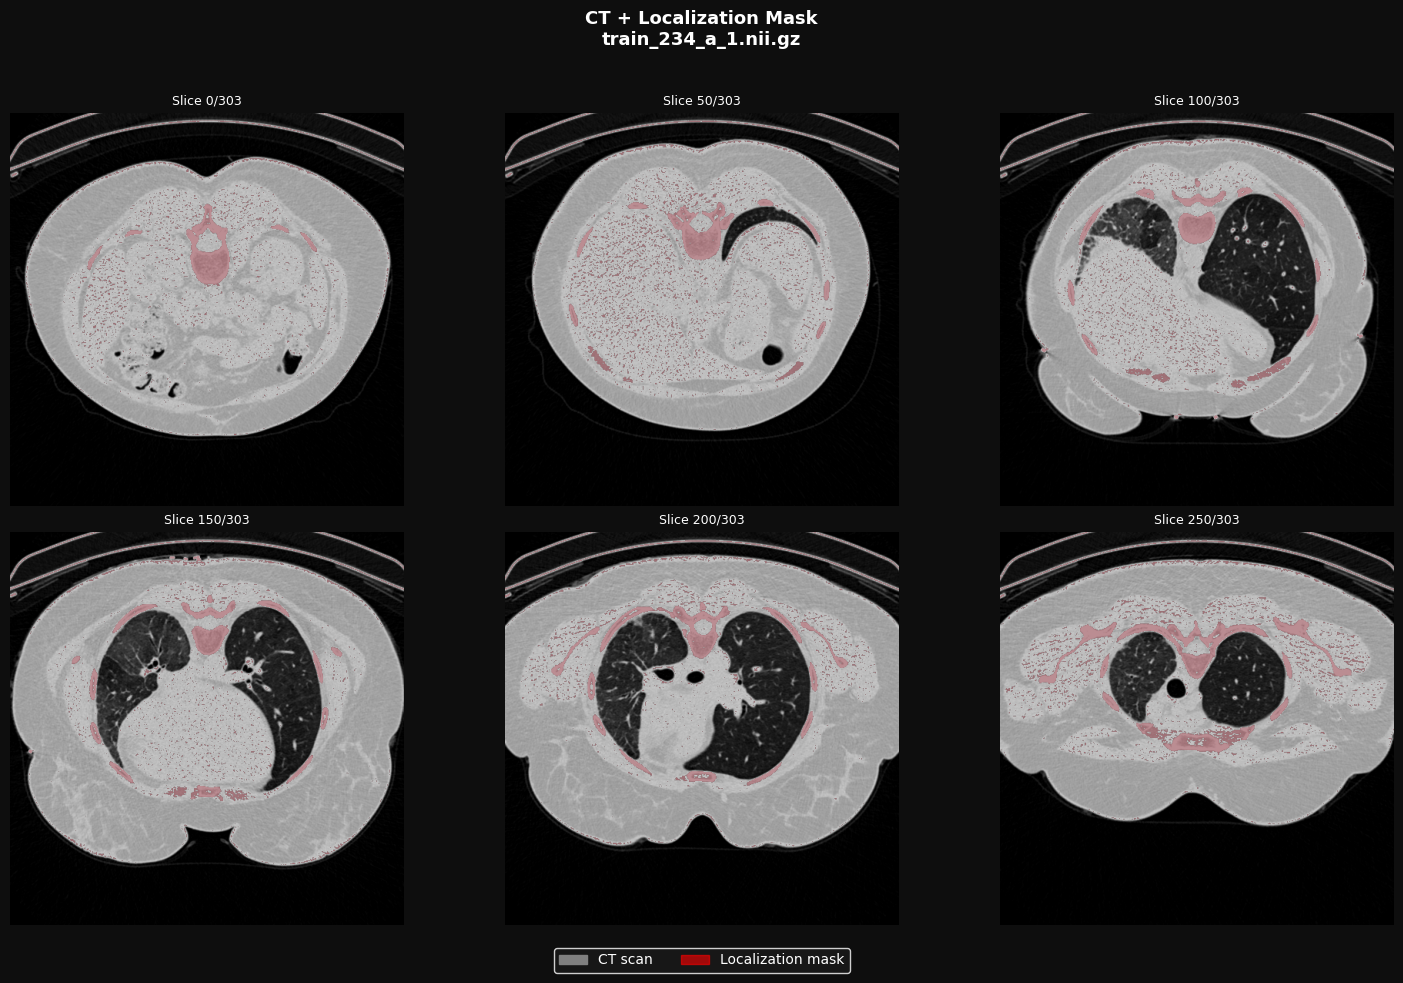

  ✓ Visualization saved → results/train_234_a_1/ct_mask_overlay.png

Processing : train_115_a_2.nii.gz
Protocol   : protocol1  |  Findings: 2
  CT loaded — shape: torch.Size([1, 1, 512, 512, 487])


In [ ]:
all_results = []

for sample in matched[:2]:
    result = run_full_pipeline(sample, model, ct_index)
    all_results.append(result)

print(f"\n{'='*55}")
print(f"DONE — {len(all_results)} volumes processed")
print(f"\nOutput structure:")
for r in all_results:
    stem = r["name"].replace(".nii.gz", "")
    print(f"\n  results/{stem}/")
    print(f"    ├── report.txt")
    print(f"    ├── embedding.npz")
    print(f"    ├── localization_mask.nii.gz")
    print(f"    ├── findings.json")
    print(f"    └── ct_mask_overlay.png")